# Lab-5

**Name:** Abdul Qudoos 
**CMS:** 023-24-0233  
**Section:** G  
**GitHub Profile:**(https://github.com/abdulqudoos181005)
**Kaggle Profile:** https://www.kaggle.com/abdulqudoos7860 

# Part 1 — Dataset, Problem & Feature/Target Identification 
## Task-1:

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df = pd.read_csv("data/train.csv")

df.head()
df.describe()
df.shape





(1460, 81)

## Task-2:

In [3]:
features = [
    "GrLivArea",
    "OverallQual",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath",
    "Neighborhood",
    "HouseStyle",
    "KitchenQual",
    "GarageType"
]

target = "SalePrice"

numeric_features = [
    "GrLivArea",
    "OverallQual",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath"
]

categorical_features = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual",
    "GarageType"
]

print("Dependent variable:", target)

print("Numerical independent variables:")
print(numeric_features)

print("Categorical independent variables:")
print(categorical_features)



Dependent variable: SalePrice
Numerical independent variables:
['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath']
Categorical independent variables:
['Neighborhood', 'HouseStyle', 'KitchenQual', 'GarageType']


## Task-3:
This is a regression problem because SalePrice is a continuous numerical value rather than a category. Therefore, we evaluate the model using regression metrics such as MAE, MSE, RMSE, and R² instead of classification metrics like accuracy.


# Part 2 — Data Preparation & Train/Test Split 
## Task-4:

In [4]:
X = df[features].copy()
y = df[target].copy()

# Fill missing numerical values
for col in numeric_features:
    X[col] = X[col].fillna(X[col].median())

# Fill missing categorical values
for col in categorical_features:
    X[col] = X[col].fillna(X[col].mode()[0])

# Convert categorical columns to numeric
X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True
)

# Make sure everything is numeric
X = X.astype(float)

print("Total missing values:", X.isnull().sum().sum())
print("All columns numeric:", all(X.dtypes != "object"))

Total missing values: 0
All columns numeric: True


justification: I used one-hot encoding for categorical features because categories such as neighborhood and house style do not have a natural numerical order. Numerical features were kept as numbers because Linear Regression can directly use them.

## Task-5


In [5]:
print("Data types:")
print(X.dtypes)

print("\nNumber of missing values:")
print(X.isnull().sum().sum())

print("\nTotal missing values in each column:")
display(X.isnull().sum())



Data types:
GrLivArea               float64
OverallQual             float64
TotalBsmtSF             float64
GarageCars              float64
YearBuilt               float64
FullBath                float64
Neighborhood_Blueste    float64
Neighborhood_BrDale     float64
Neighborhood_BrkSide    float64
Neighborhood_ClearCr    float64
Neighborhood_CollgCr    float64
Neighborhood_Crawfor    float64
Neighborhood_Edwards    float64
Neighborhood_Gilbert    float64
Neighborhood_IDOTRR     float64
Neighborhood_MeadowV    float64
Neighborhood_Mitchel    float64
Neighborhood_NAmes      float64
Neighborhood_NPkVill    float64
Neighborhood_NWAmes     float64
Neighborhood_NoRidge    float64
Neighborhood_NridgHt    float64
Neighborhood_OldTown    float64
Neighborhood_SWISU      float64
Neighborhood_Sawyer     float64
Neighborhood_SawyerW    float64
Neighborhood_Somerst    float64
Neighborhood_StoneBr    float64
Neighborhood_Timber     float64
Neighborhood_Veenker    float64
HouseStyle_1.5Unf       floa

GrLivArea               0
OverallQual             0
TotalBsmtSF             0
GarageCars              0
YearBuilt               0
FullBath                0
Neighborhood_Blueste    0
Neighborhood_BrDale     0
Neighborhood_BrkSide    0
Neighborhood_ClearCr    0
Neighborhood_CollgCr    0
Neighborhood_Crawfor    0
Neighborhood_Edwards    0
Neighborhood_Gilbert    0
Neighborhood_IDOTRR     0
Neighborhood_MeadowV    0
Neighborhood_Mitchel    0
Neighborhood_NAmes      0
Neighborhood_NPkVill    0
Neighborhood_NWAmes     0
Neighborhood_NoRidge    0
Neighborhood_NridgHt    0
Neighborhood_OldTown    0
Neighborhood_SWISU      0
Neighborhood_Sawyer     0
Neighborhood_SawyerW    0
Neighborhood_Somerst    0
Neighborhood_StoneBr    0
Neighborhood_Timber     0
Neighborhood_Veenker    0
HouseStyle_1.5Unf       0
HouseStyle_1Story       0
HouseStyle_2.5Fin       0
HouseStyle_2.5Unf       0
HouseStyle_2Story       0
HouseStyle_SFoyer       0
HouseStyle_SLvl         0
KitchenQual_Fa          0
KitchenQual_

## Task-6:

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1168, 45)
X_test : (292, 45)
y_train: (1168,)
y_test : (292,)


# Part 3 — Linear Regression & Predictions 
## Task-7:

In [7]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## task-8:


In [8]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

display(comparison.head(10))

,Actual Price,Predicted Price
0,154500,139407.401140
1,325000,320376.566477
2,115000,112383.121314
3,159000,171441.741427
4,315500,318644.598365
5,75500,66037.209937
6,311500,239170.096394
7,146000,148284.769071
8,84500,65728.355759
9,135500,121560.881681


# Part 4:

## Task-9:


In [9]:
coef_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_table["Interpretation"] = coef_table["Coefficient"].apply(
    lambda x: f"A one-unit increase is associated with a change of about {x:,.2f} in predicted price, holding other features constant."
)

display(coef_table)

print("Intercept:", model.intercept_)

,Feature,Coefficient,Interpretation
0,GrLivArea,54.664639,A one-unit increase is associated with a chang...
1,OverallQual,12125.827927,A one-unit increase is associated with a chang...
2,TotalBsmtSF,6.068088,A one-unit increase is associated with a chang...
3,GarageCars,14248.957266,A one-unit increase is associated with a chang...
4,YearBuilt,154.427089,A one-unit increase is associated with a chang...
5,FullBath,-280.353680,A one-unit increase is associated with a chang...
6,Neighborhood_Blueste,-1551.546560,A one-unit increase is associated with a chang...
7,Neighborhood_BrDale,5596.030457,A one-unit increase is associated with a chang...
8,Neighborhood_BrkSide,26782.638349,A one-unit increase is associated with a chang...
9,Neighborhood_ClearCr,53520.806531,A one-unit increase is associated with a chang...


Intercept: -336432.7323910139


## Task-10:

Answer: The intercept does not have a very useful real-world interpretation here because it represents the predicted price when all features are zero. A real house would not realistically have zero living area, zero quality, zero bathrooms, and zero other features.


# Part-5:

## Task-11:


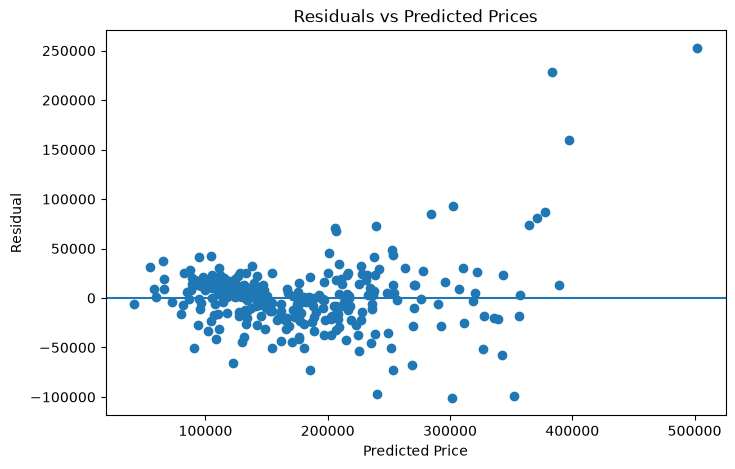

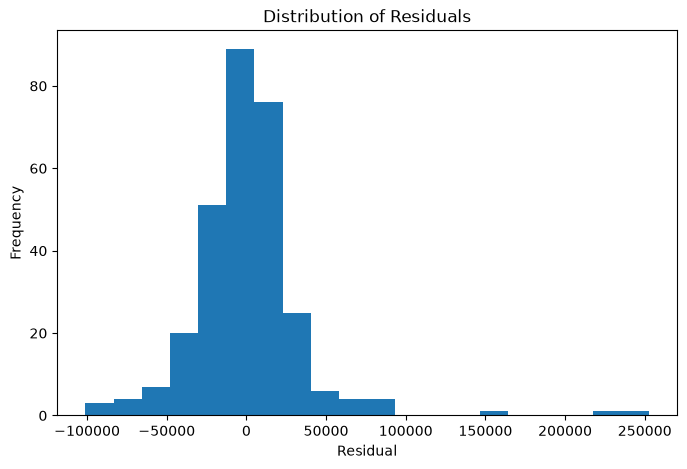

In [10]:
residuals = y_test - y_pred


plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Prices")

plt.show()


plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=20)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")

plt.show()

## TAsk-12:


In [11]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae, mse, rmse, r2]
})

display(metrics)

,Metric,Value
0,MAE,2.155977e+04
1,MSE,1.225906e+09
2,RMSE,3.501294e+04
3,R²,8.401755e-01


## Task-13:
Answer: I would show MAE to a non-technical stakeholder because it is easy to understand. For example, if the MAE is $25,000, I can simply explain that the model's predictions are off by about $25,000 on average.


# Part-6:

## Task-14:


In [12]:
train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

performance = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Training": [
        train_mae,
        train_mse,
        train_rmse,
        train_r2
    ],
    "Testing": [
        test_mae,
        test_mse,
        test_rmse,
        test_r2
    ]
})

display(performance)

,Metric,Training,Testing
0,MAE,2.046454e+04,2.155977e+04
1,MSE,1.040429e+09,1.225906e+09
2,RMSE,3.225568e+04,3.501294e+04
3,R²,8.255646e-01,8.401755e-01


## Task-15:
Answer: There is a relatively small difference between the training and testing performance. This suggests that the model generalizes reasonably well and does not show severe overfitting.

## Task-16:


In [13]:
coef_table_sorted = coef_table.copy()

coef_table_sorted["Absolute Coefficient"] = (
    coef_table_sorted["Coefficient"].abs()
)

display(
    coef_table_sorted
    .sort_values("Absolute Coefficient", ascending=False)
    .head(10)
)

,Feature,Coefficient,Interpretation,Absolute Coefficient
20,Neighborhood_NoRidge,78708.359596,A one-unit increase is associated with a chang...,78708.359596
27,Neighborhood_StoneBr,65388.201769,A one-unit increase is associated with a chang...,65388.201769
21,Neighborhood_NridgHt,59667.412875,A one-unit increase is associated with a chang...,59667.412875
29,Neighborhood_Veenker,57528.679847,A one-unit increase is associated with a chang...,57528.679847
37,KitchenQual_Fa,-54885.756505,A one-unit increase is associated with a chang...,54885.756505
39,KitchenQual_TA,-53554.724380,A one-unit increase is associated with a chang...,53554.724380
9,Neighborhood_ClearCr,53520.806531,A one-unit increase is associated with a chang...,53520.806531
11,Neighborhood_Crawfor,50816.985635,A one-unit increase is associated with a chang...,50816.985635
42,GarageType_BuiltIn,46258.449885,A one-unit increase is associated with a chang...,46258.449885
40,GarageType_Attchd,45788.925305,A one-unit increase is associated with a chang...,45788.925305


## Task-17:
Answer: The Linear Regression model was able to predict house prices using selected numerical and categorical features. The test metrics show how close the predicted prices were to the actual prices. I would use MAE when explaining the model to a non-technical stakeholder because it gives the average prediction error in price units. The coefficient table shows that features such as overall quality and living area have a strong relationship with house prices. However, coefficient size should be interpreted carefully because the features use different scales. Linear Regression also has limitations because house prices can have complex and non-linear relationships that a straight-line model cannot fully capture. As a next step, I would try models such as Random Forest or other regression methods and compare their performance.